In [34]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import ttest_ind
from config import Results_OUTPUT_PATH

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)


In [11]:
df = pd.read_csv(Results_OUTPUT_PATH)
df.head()


,platform,hashtag,status_id,created_at,account_id,account_name,url,replies_count,reblogs_count,favourites_count,...,visibility,content_text,sentiment_polarity,sentiment_subjectivity,toxicity_toxicity,toxicity_severe_toxicity,toxicity_obscene,toxicity_threat,toxicity_insult,toxicity_identity_attack
0,mastodon,ActuallyAutistic,115669417493343638,2025-12-05T22:53:58+00:00,113047730416315829,punishmenthurts@autistics.life,https://autistics.life/@punishmenthurts/115669...,0,0,0,...,public,just found my comment to them about the first ...,-0.086676,0.574863,0.030302,0.000340,0.004275,0.000336,0.003141,0.001162
1,mastodon,ActuallyAutistic,115669393524984799,2025-12-05T22:47:52+00:00,113047730416315829,punishmenthurts@autistics.life,https://autistics.life/@punishmenthurts/115669...,0,1,0,...,public,I think I've managed to add the first three ap...,0.096591,0.391970,0.000708,0.000111,0.000174,0.000118,0.000178,0.000139
2,mastodon,ActuallyAutistic,115669294472969667,2025-12-05T22:22:42+00:00,115345760446260255,mijei@xarxa.cloud,https://xarxa.cloud/@mijei/115669294275957900,0,0,1,...,public,"""Durante mucho tiempo, los intereses especiale...",0.000000,0.000000,0.037255,0.000201,0.002366,0.000408,0.001148,0.000594
3,mastodon,ActuallyAutistic,115669125470046914,2025-12-05T21:39:42+00:00,113047730416315829,punishmenthurts@autistics.life,https://autistics.life/@punishmenthurts/115669...,0,0,0,...,public,that was a new one comparing Human Nature to q...,0.005195,0.431602,0.000788,0.000109,0.000173,0.000111,0.000181,0.000145
4,mastodon,ActuallyAutistic,115669055811754664,2025-12-05T21:22:01+00:00,115345760446260255,mijei@xarxa.cloud,https://xarxa.cloud/@mijei/115669055692887779,0,0,0,...,public,¿A ti también te han dicho eso de que no puede...,0.000000,0.000000,0.039447,0.000175,0.001655,0.000345,0.001123,0.000651


In [12]:
df.shape

(2098, 21)

In [13]:

df.columns


Index(['platform', 'hashtag', 'status_id', 'created_at', 'account_id',
       'account_name', 'url', 'replies_count', 'reblogs_count',
       'favourites_count', 'sensitive', 'visibility', 'content_text',
       'sentiment_polarity', 'sentiment_subjectivity', 'toxicity_toxicity',
       'toxicity_severe_toxicity', 'toxicity_obscene', 'toxicity_threat',
       'toxicity_insult', 'toxicity_identity_attack'],
      dtype='object')

In [16]:
df = df.dropna(subset=["content_text"])
df = df[df["content_text"].str.strip().str.len() > 0]
df.shape


(2098, 21)

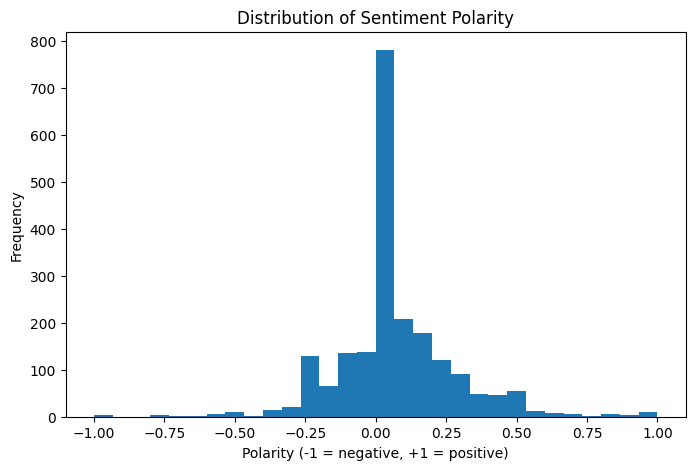

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df["sentiment_polarity"], bins=30)
plt.title("Distribution of Sentiment Polarity")
plt.xlabel("Polarity (-1 = negative, +1 = positive)")
plt.ylabel("Frequency")
plt.show()


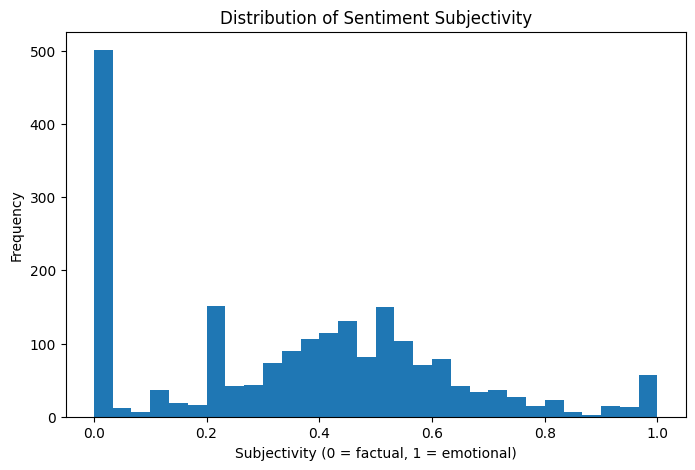

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df["sentiment_subjectivity"], bins=30)
plt.title("Distribution of Sentiment Subjectivity")
plt.xlabel("Subjectivity (0 = factual, 1 = emotional)")
plt.ylabel("Frequency")
plt.show()


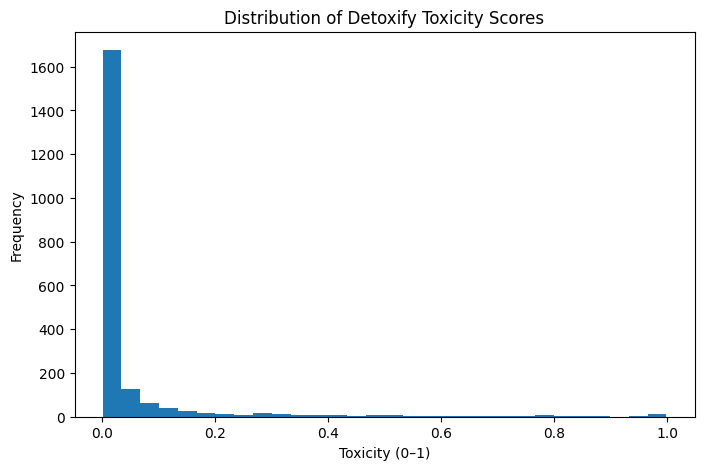

In [19]:
plt.figure(figsize=(8,5))
plt.hist(df["toxicity_toxicity"], bins=30)
plt.title("Distribution of Detoxify Toxicity Scores")
plt.xlabel("Toxicity (0–1)")
plt.ylabel("Frequency")
plt.show()


In [35]:
df.nlargest(10, "toxicity_toxicity")[["content_text", "toxicity_toxicity"]]


,content_text,toxicity_toxicity
524,"GOD FUCKING DAMNIT I'M SO ANGRY THAT I COULD BITE MY OWN EYEBALLS hey, friendo.. you're overstimulated by being itchy and sore. go get a shower. # audhd # autism # adhd # disability",0.998415
883,🖕🏻🖕🏻🖕🏻🖕🏻🖕🏻🖕🏻🖕🏻🖕🏻 \n \n #fuckracism #fuckbigotry #sorrynotsorry #fuckthefarright #ihatethefarright #fuckreformuk #fuckthetories #fucknigelfarage #uk #unitedkindom #notoreform #refugeeswelcome #loveislove #fuckdonaldtrump #fuckabelism #orangeprick #getfucked #autismacceptance #actuallyautistic #autisticadult #fuckrfk #fuckukip,0.998207
1758,"RE: https:// fuckaas.space/@fuckfetish/1156 14470368701800 ""autism4autism relationships are the best because autistic people communicate with each other in a way no allistic person ever could"" no autism4autism is you & your partner screeching most bizarre & unnerving vocal stims at each other until one of you loses the will to live (jk autism4autism4eva) # autism # neurodivergent # shitpost",0.996042
435,"These fucking letting agents and landlords are going to end me with what they think is acceptable. Since 1pm the rcd switch has been going off, taking longer to reset. It’s now been over 2 hours since it last reset and my emergency torches aren’t working. They told me let it dry out, that was their advice! We couldn’t plug anything into a socket, then it tripped when a bedroom light was put on. # AUDHD # Renting # UK",0.994741
1294,"To all the misunderstood, weirdos, unintentional ""assholes"", unique and mega talented autistic minds out there surfing the daily challenges of this world.... YOU fucking rock! 🤟 Know that you are loved! 🙌🤗 # autistic # autism # actuallyautistic # autisticlegion # aspergers # autismawareness # autismacceptance # asd # adhd # autismo # autismspectrum # neurodiversity # neurodivergent # autismawarenessmonth # autismworld https://www. youtube.com/watch?v=ej2c013Hcr A",0.990376
1638,"# TransAwarenessWeek makes me feel like # AutismAwarenessMonth - hypervigilant, irritable, annoyed, tired, and unsafe. # FuckAwareness and # FuckAcceptance too. # TransBelligeranceWeek I will be # AggressivelyGender all week.",0.986300
1137,"@ JugglingWithEggs Well Dr Suzanne O’Sullivan clearly knows ABSOLUTELY FUCK ALL about autism. FUMING! I have no experience of the other conditions but have direct, lived experience of the struggles of a person with autism. How completely unprofessional to pontificate on a topic which is not her specialty! # ASD # Autism # Autistic",0.984019
1862,"Of course, I'll probably wake up tomorrow and regret writing this before immediately deleting it. #MentalHealth #MH #ActuallyAutistic #WellAspergersReally #ADHD #Aspergers #ASD1 #ASC1 #Neurodivergent #FuckingArsehole #PointlessSelfTherapy",0.982537
1730,"don't tell me how you're a weirdo who answers rhetorical questions, tell me about how you're a normal person and WHAT THE FUCK IS A RHETORICAL ""QUESTION??!?!?!"" . # actuallyautistic @autistics # ActualllyAutistic # autism",0.981591
228,"I reply intelligently, get a supercilious insult, respond accordingly... and THEY don't tolerate ""u kindness""[sic] ?!?! Make it make sense. Am I NOT # autistic because I'm actually fucking self-aware and NOT up my own ass?! 🙄",0.977236


In [36]:
false_positives = df[
    (df["sentiment_polarity"] > -0.1) &
    (df["toxicity_toxicity"] > 0.4)
]

false_positives[["content_text", "sentiment_polarity", "toxicity_toxicity"]].head(20)


,content_text,sentiment_polarity,toxicity_toxicity
17,"a coworker within my health system, not in my department, is nominating me for an award for being an extremely helpful and attentive employee. eat a dick last boss at this health system that told me when i went on leave of absence that i was the *worst* employee she ever hired and literally the least grateful and most disrespectful person she ever met.* *i did, in fact, report her to HR who told me although what my manager said was ""highly unprofessional"", she ""didn't do anything to violate company policy"". pffffttt this whole incident prompted me to be assessed for autism again. # actuallyautistic",-0.019722,0.469186
54,"Feeling a bit of an asshole for saying this, but meetings without arbitration/moderation are not accessible . Even less if everyone talks at the same time disregarding collisions/interrupting, and/or there's multiple conversations going on at the same time. Less of all if everyone shouts . And in low light conditions when one can't read facial expressions or sometimes even identify who's talking... well, some people I know overload and run the fuck away. Good thing I didn't go for the old meltdown, it's an ugly thing to see in a middle-aged tranny. # ActuallyAutistic",-0.032372,0.795382
62,However someone responds to you telling them you’re autistic has a lot more to do with them than with you. # unmasking # AutisticMasking # ActuallyAutistic # Autistic # Neurodiversity,0.033333,0.429805
65,"I am taking it real fucking easy today after two packed days and because I am taking part in an after work social activity tonight. For once it doesn't involve going to a loud restaurant and playing bar games, so it is much more autism friendly. We'll just be 10-ish people, order pizza and build some gingerbread houses! I'm glad they took my feedback to vary activities to heart! # ActuallyAutistic",0.360069,0.952339
66,"Autistic man needs to be right in ways that matter least An autistic man desperately needs to be factually correct about things nobody else gives a shit about, his loved ones have reported. Ben Espenson, 38, reportedly has the option to simply let small things go, but instead chooses to insist he’s right about inane nonsense... ActuallyAutistic",-0.047857,0.462730
78,"It doesn't necessarily mean they are stinky and need to shower. All living beings have a smell, no natter how clean they are. What they use in the shower also contributes to their smell. # ActuallyAutistic",0.027083,0.530697
90,"back to the original socks in this thread. heel is done so i can get bit better photo. i think the reason why i knit like this is that my AuDHD ass doesn’t get bored. each row & the end result is unpredictable. i was not looking forward to these bc i thought it would look plain & boring! got that blue striped yarn from a lot i purchased. would not have bought it otherwise. but surprise, they are fucking gorgeous. # ActuallyAutistic # knitting # craftodom # handicrafts @ autistics",-0.040595,0.874153
95,"> Supplement Mix Reverses Autism Traits https:// neurosciencenews.com/supplemen ts-reverse-asd-30005/ Like hell, they say! Here's assholes still trying to force a ""cure"" for what doesn't need curing. # actuallyautistic @ autistics",0.000000,0.871705
105,"Alright I have this toxic idiotic weird thing where for whatever reason when someone is being an ass to me I just decide to go full ""I'm going to criticize you but also be encouraging because I want you to be a better and happy person and we will SOLVE THIS PROBLEM TOGETHER"" and I can't even let the situation be a normal angry interaction because I need to meet with that person's soul and align and come to mutual understanding and see each other through that, like I'm unsatisfied with rejection and we must arrive at closure and I'm now dragging you down with me into deep reflective discussion ...why am I like this?? 😂 I feel like I should be grateful that hasn't put me in a lot more toxic situations or piss

In [37]:
len(false_positives), len(df)


(56, 2098)

In [23]:
100 * len(false_positives) / len(df)


2.669208770257388

In [24]:
df[["sentiment_polarity", "toxicity_toxicity"]].corr()


,sentiment_polarity,toxicity_toxicity
sentiment_polarity,1.000000,-0.125648
toxicity_toxicity,-0.125648,1.000000


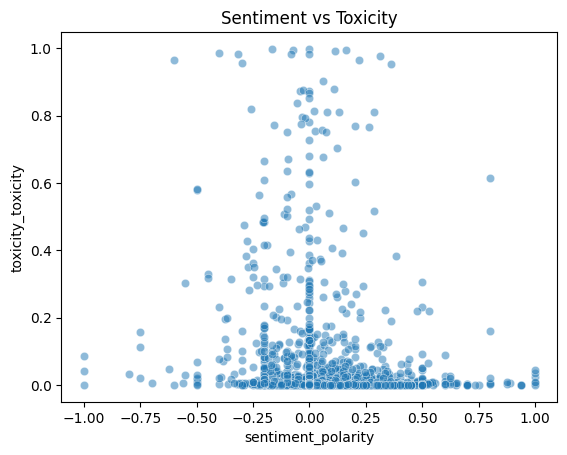

In [25]:
sns.scatterplot(x="sentiment_polarity", y="toxicity_toxicity", data=df, alpha=0.5)
plt.title("Sentiment vs Toxicity")
plt.show()


In [26]:
df.groupby("hashtag")["toxicity_toxicity"].mean().sort_values(ascending=False)


hashtag
autismadvocate            0.113796
autism                    0.084454
aspergers                 0.079029
ActuallyAutistic          0.074460
Autistic                  0.061101
AuDHD                     0.057847
autismacceptance          0.056681
AutisticPride             0.052713
autismawarenessmonth      0.050810
autismawareness           0.035210
autismspectrum            0.031303
autismspectrumdisorder    0.030275
asd                       0.020125
asc                       0.017276
autismlife                0.015497
autismjourney             0.007267
autismrocks               0.002454
Name: toxicity_toxicity, dtype: float64

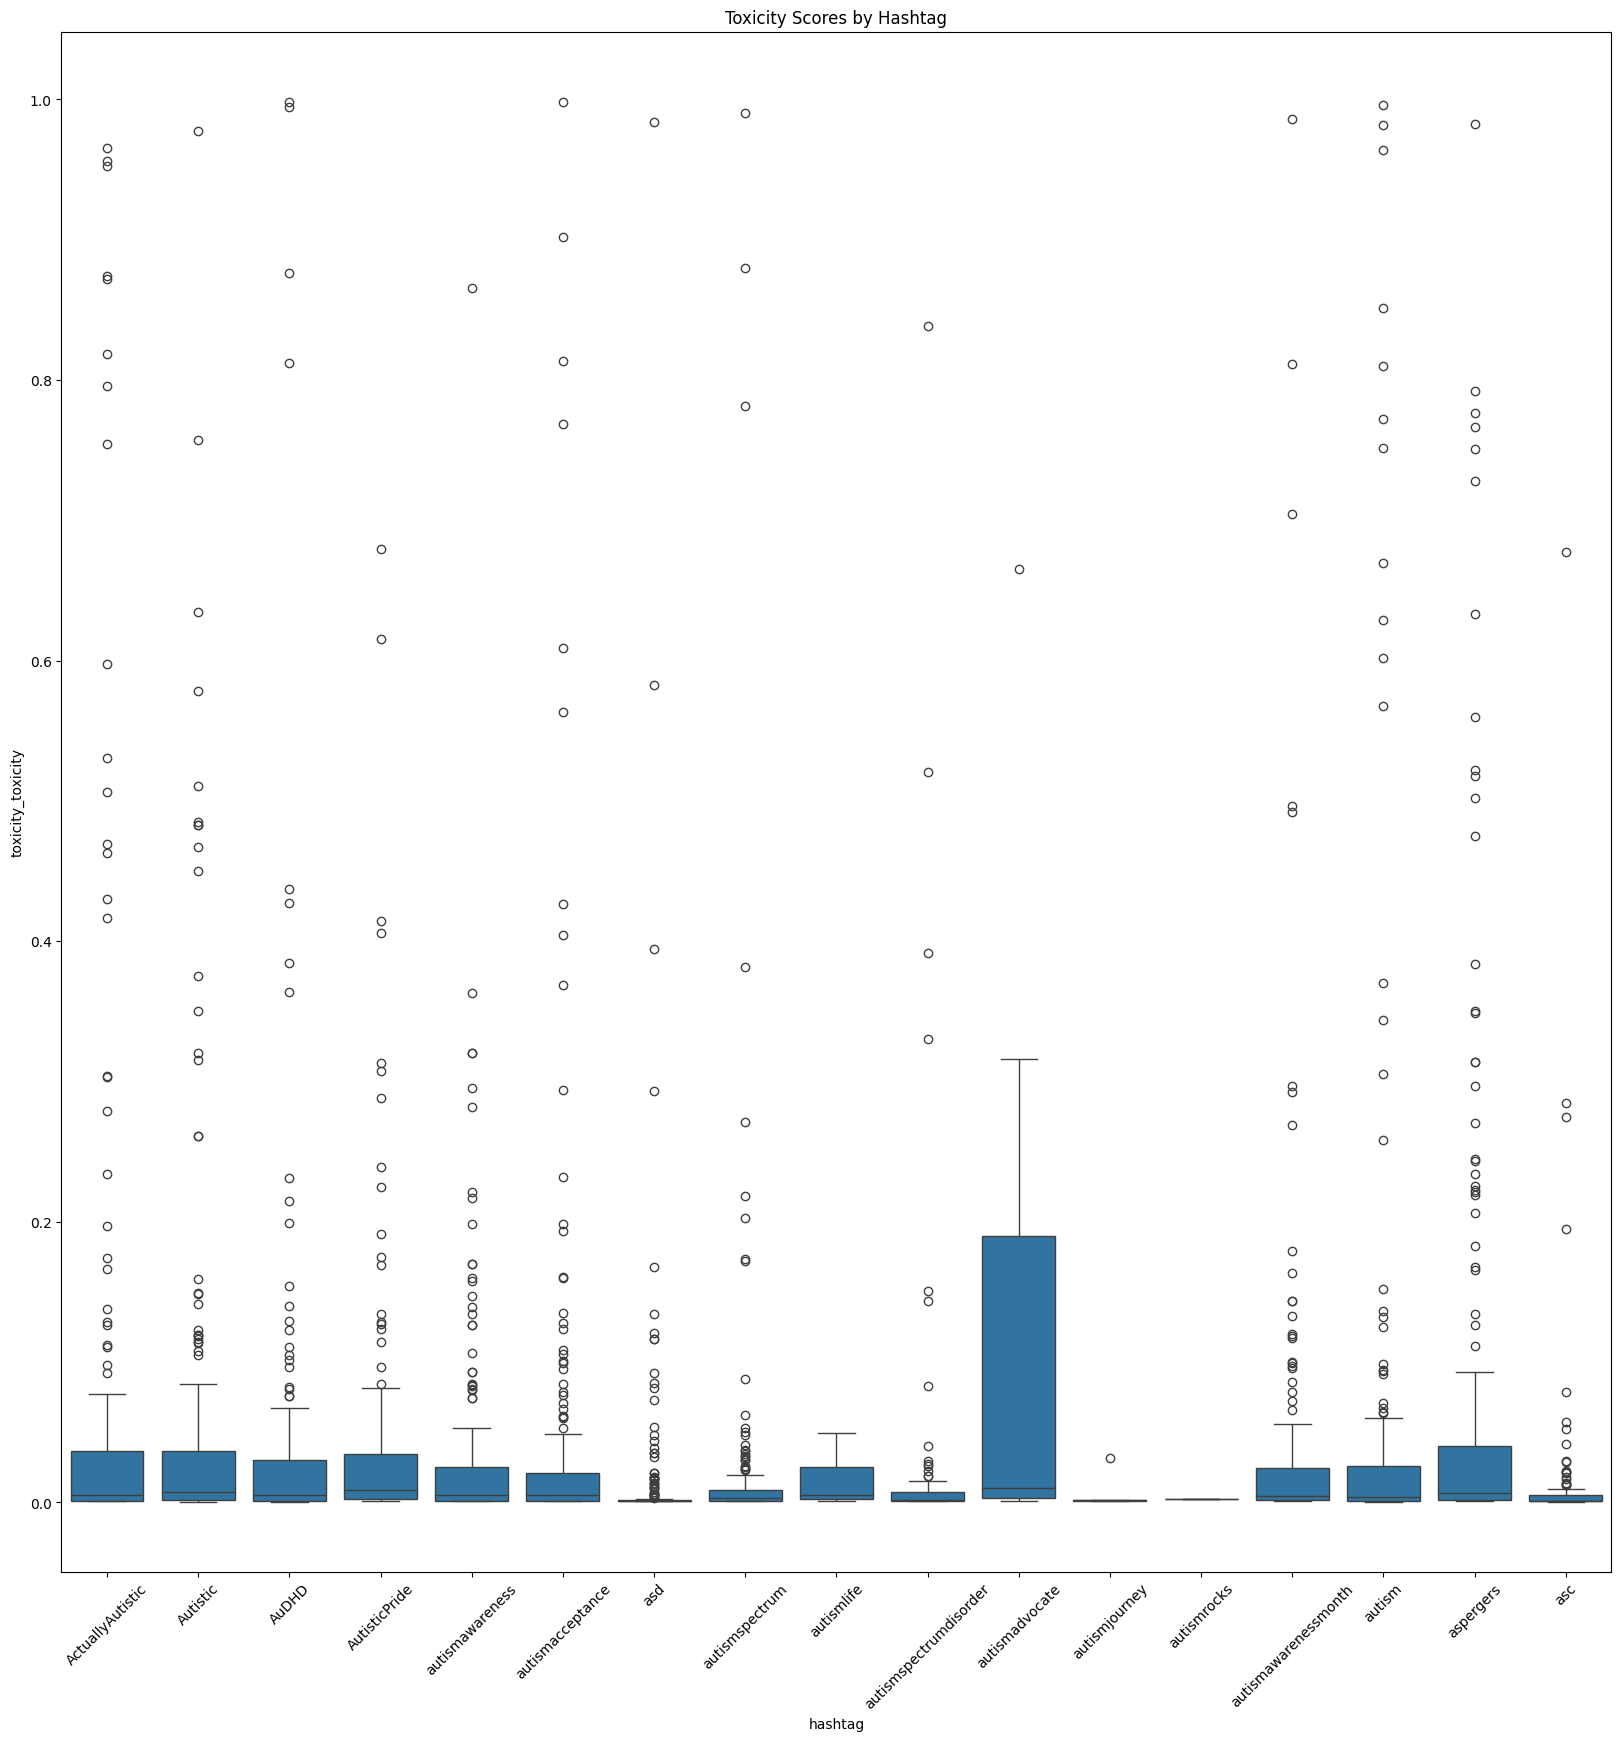

In [31]:
plt.figure(figsize=(20,20))
sns.boxplot(x="hashtag", y="toxicity_toxicity", data=df)
plt.xticks(rotation=45)
plt.title("Toxicity Scores by Hashtag")
plt.show()


In [32]:
aa = df[df["hashtag"]=="ActuallyAutistic"]["toxicity_toxicity"]
other = df[df["hashtag"]!="ActuallyAutistic"]["toxicity_toxicity"]

ttest_ind(aa, other, equal_var=False)


TtestResult(statistic=np.float64(1.8371824371596905), pvalue=np.float64(0.06751939066516129), df=np.float64(222.04997583399276))

In [33]:
cohen_d = (aa.mean() - other.mean()) / np.sqrt((aa.std()**2 + other.std()**2) / 2)
cohen_d


np.float64(0.15235602362683948)